#  Praktikum 3: GPU Programming in Triton

The aim of the lab is understanding GPU programming. After completing this lab,
* you will have a mental model of how parallel programs run on GPU.
* How to implement, test, benchmark, and tune GPU implementations.

by implementing following tasks.
1. Write optimized matrix multiplication on GPU in Triton. Assumption: C
2. Test, benchmark, and tune for throughput on a modern GPU hardware.

## Setup

Triton is a python-based domain specific language for writing GPU code.

### Prerequisites

 The following code installs triton. The notebook requires a CUDA-capable GPU. Open the notebook on a CUDA box (Colab, a workstation with an NVIDIA GPU, EFI GPU Cluster or a cloud instance). It is *not* runnable on macOS or CPU-only machines. The DEVICE should show CUDA if GPU is selected as an accelerator.

In [1]:
!pip install triton torchprofile -q
import torch
import triton
import triton.language as tl
import time

torch.manual_seed(0); torch.cuda.manual_seed_all(0)
DEVICE = triton.runtime.driver.active.get_active_torch_device()
print(DEVICE)

zsh:1: command not found: pip


ModuleNotFoundError: No module named 'triton'

### Utilities

Following simple helper functions can be used for benchmarking your gpu implementation of matrix multiplication and measuring the throughput in GFLOPS (Assumption: Square Matrix).

In [ ]:
# Usage Example: bench(lambda: simple_matmul(A, B))
def bench(fn, warmup=2, reps=20):
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()
    start = time.time()
    for _ in range(reps):
        fn()
    torch.cuda.synchronize()
    end = time.time()
    return (end - start) * 1000 / reps  # ms

def gflops(N, time_ms):
    """GFLOPS for an N x N square matmul: FLOPs = 2 * N^3."""
    return 2 * N**3 / (time_ms * 1e-3) / 1e9

def kernel_info(jit_fn):
    """Return compile-time stats for any cached variant of jit_fn.
    Walks whichever cache structure this Triton version uses."""
    # Triton has used: `cache`, `device_caches` — find whichever exists.
    cache = None
    for attr in ("device_caches", "cache"):
        if hasattr(jit_fn, attr):
            cache = getattr(jit_fn, attr)
            break
    if not cache:
        return None

    # The cache is a nested mix of dicts / tuples / lists ending in a
    # CompiledKernel (which has a `.metadata` attribute). Walk recursively.
    def find_compiled(obj, depth=0):
        if depth > 5 or obj is None:
            return None
        if hasattr(obj, "metadata") and not isinstance(obj, (dict, list, tuple)):
            return obj
        if isinstance(obj, dict):
            for v in obj.values():
                r = find_compiled(v, depth + 1)
                if r is not None:
                    return r
        elif isinstance(obj, (tuple, list)):
            for v in obj:
                r = find_compiled(v, depth + 1)
                if r is not None:
                    return r
        return None

    k = find_compiled(cache)
    if k is None:
        return None
    md = k.metadata
    return dict(
        n_regs       = getattr(k,  "n_regs",     None),
        n_spills     = getattr(k,  "n_spills",   None),
        shared_bytes = getattr(md, "shared",     None),
        num_warps    = getattr(md, "num_warps",  None),
        num_stages   = getattr(md, "num_stages", None),
    )

## GPU Characterzation

**Task 1**

Find out the following information about the GPU from torch (`torch.cuda.get_device_properties(0)`), datasheet, or wikipedia.
* GPU
* SRAM, Shared memory per SM
* L2 Cache
* VRAM
* Number of Streaming Multiprocessors (SM)
* Peak Performance (FP32): Compute peak FP32 from first principles using your card's SM count, FP32 cuda cores per SM, and clock.
* Peak Performance (FP16)
* Peak DRAM bandwidth (GB/s)
* ...

In [ ]:
props = torch.cuda.get_device_properties(0)
GPU_NAME = props.name

# e.g.
PEAK_FP32_TFLOPS = 8.1    # Try to derive the number

# TODO
PEAK_FP16_TFLOPS = 65
PEAK_BW = 320

print(f"GPU                         : {GPU_NAME}")
print(f"Compute Capability          : {props.major}.{props.minor}")
print(f"Streaming Multiprocessors   : {props.multi_processor_count}")
print(f"VRAM (total)                : {props.total_memory / 1024**3:.2f} GiB")
print(f"Shared Memory / SM          : {props.shared_memory_per_block / 1024:.0f} KiB")
print(f"L2 Cache                    : {props.L2_cache_size / 1024**2:.2f} MiB")



print(f"\nPeak FP32 (datasheet)       : {PEAK_FP32_TFLOPS} TFLOPS")
print(f"Peak FP16 (tensor cores)    : {PEAK_FP16_TFLOPS} TFLOPS")
print(f"Peak DRAM BW (datasheet)    : {PEAK_BW} GB/s\n")

## Matrix Multiplication on GPU

A simple matrix multiplication $C[m,n] = \sum A[m,k] * B[k,n]$ loads each element of A and B once per output element. Following is a Triton kernel that launches a 2-D grid of size `(N, N)`.
Assumption:
* Square matrix
* fp32 datatype

In [ ]:
@triton.jit
def simple_matmul_kernel(a_ptr, b_ptr, c_ptr, N):
    pid_m = tl.program_id(0)   # row index
    pid_n = tl.program_id(1)   # column index

    acc = 0.0

    for k in range(N):
        a_val = tl.load(a_ptr + pid_m * N + k)
        b_val = tl.load(b_ptr + k * N + pid_n)
        acc += a_val * b_val

    tl.store(c_ptr + pid_m * N + pid_n, acc)

def simple_matmul(a, b):
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=a.dtype)
    simple_matmul_kernel[(N, N)](a, b, c, N)

    return c

**Task 2**
* Run and verify correctness against `torch.matmul` for `N = 64`.
* Execution Model: Which part of the above code runs on CPU and GPU respectively?
* SIMT Execution Model: How many triton programs are launched for `N = 64`?
* SIMT Execution Model: What is the program_id of triton program which calculates C[1,1]
* Memory Model: What is total number of load and store from one triton program.
* Memory Model: What is the total number of floating point operation per triton program
* Arithmetic intensity (AI): how many total bytes are moved? What is the (FLOPs / byte) of this kernel?

## Task 2: Solution

**Execution Model: CPU vs GPU**
- **CPU**: `def simple_matmul(a, b)` — the Python wrapper that allocates `c` and calls `simple_matmul_kernel[grid](...)`.
- **GPU**: `simple_matmul_kernel` (decorated with `@triton.jit`) — JIT-compiled to PTX and executed on the device.

**SIMT: Programs launched for N = 64**
Grid shape is `(N, N) = (64, 64)` → **4 096 Triton programs** (one per output element).

**SIMT: program_id for C[1, 1]**
`pid_m = tl.program_id(0) = 1`,  `pid_n = tl.program_id(1) = 1` → program **(1, 1)**.

**Memory Model: loads and stores per program**
Each program iterates `k` over `range(N=64)`, issuing:
- 1 load from A + 1 load from B per iteration → **128 loads** (512 bytes)
- 1 store to C after the loop → **1 store** (4 bytes)

**FLOPs per program**
1 multiply + 1 add per `k` → 2 FLOPs × 64 = **128 FLOPs**.

**Arithmetic Intensity**
| Scope | FLOPs | Bytes moved | AI |
|---|---|---|---|
| Per program | 128 | 516 B (128 ld × 4 B + 1 st × 4 B) | **0.25 FLOPs/byte** |
| Whole kernel (no reuse) | 2N³ = 524 288 | N² × 516 B ≈ 2.05 MB | **0.25 FLOPs/byte** |
| Whole kernel (perfect L2 reuse) | 524 288 | 3 × N² × 4 B = 48 KiB | **~10.7 FLOPs/byte** |

The naive kernel has **no data reuse**: every program re-loads its row of A and column of B independently, so the effective AI ≈ 0.25 FLOPs/byte — far below the compute-to-bandwidth ratio of a T4 (~25 FLOPs/byte at FP32 peak), making this kernel **heavily memory-bound**.

In [ ]:
N = 64
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

torch.testing.assert_close(simple_matmul(A, B), torch.matmul(A, B), atol=1e-2, rtol=0)
print("Correctness check passed for N =", N)

# Benchmarking Performance

**Task 3**
* Measure mean GPU kernel time for naive matrix multiplication (N=1024) in milliseconds.
* What is the throughput of the naive GPU implementation in gflops?
* Is it higher compared to Optimized CPU implementation in Lab 2? Compare to your card's peak performance derived in Task 1.
* kernel_info return compile-time stats for any triton matmul kernel, showing register and shared memory usage. What is the reason that the Naive implementation is slow.

In [ ]:
N = 1024
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
info = kernel_info(simple_matmul_kernel)

print(info)

t = bench(lambda: simple_matmul(A, B))
# TODO:
print(f"Kernel execution time: {t} ms")
print(f"Gflops: {gflops(N, t)} ")

# Optimization: Vectorization

The kernel `naive_matmul_kernel` upgrades the scalar loop in `simple_matmul_kernel` to a **vectorized** loop. Instead of loading one float per iteration and adding seuquentially. It loads a vector of `BLOCK_K` floats, multiplies element-wise, and reduces with `tl.sum`.

**Task 4**
* Run, verify, and benchmark correctness against `torch.matmul` for `N = 64`. By what factor does vectorization speed things up?
* SIMT Execution Model: How many triton programs are launched for `N = 64`?
* SIMT Execution Model: How many threads are actually doing useful work per program? How is the dot product computed over time (step-by-step work)?
* What is the fundamental bottleneck that vectorization alone cannot fix?

In [ ]:
@triton.jit
def naive_matmul_kernel(a_ptr, b_ptr, c_ptr, N, BLOCK_K: tl.constexpr):
    pid_m = tl.program_id(0)         # row of C
    pid_n = tl.program_id(1)         # col of C

    acc = tl.zeros((BLOCK_K,), dtype=tl.float32)
    for k in range(0, N, BLOCK_K):
        offs_k = k + tl.arange(0, BLOCK_K)
        a = tl.load(a_ptr + pid_m * N + offs_k)            # vector of BLOCK_K floats
        b = tl.load(b_ptr + offs_k * N + pid_n)            # vector of BLOCK_K floats (strided)
        acc += a * b

    result = tl.sum(acc, axis=0)                           # warp reduction
    tl.store(c_ptr + pid_m * N + pid_n, result)


def naive_matmul(a, b, BLOCK_K=128):
    N = a.shape[0]
    c = torch.empty((N, N), device=a.device, dtype=torch.float32)
    grid = (N, N)
    naive_matmul_kernel[grid](a, b, c, N, BLOCK_K=BLOCK_K, num_warps=4)
    return c

N = 1024
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
info = kernel_info(naive_matmul_kernel)

print(info)

t = bench(lambda: naive_matmul(A, B))
# TODO:
print(f"Kernel execution time: {t} ms")
print(f"Gflops: {gflops(N, t)} ")

# Optimization: Tiled Matrix Multiplication

The naive kernel 100× below peak performance. It spends almost all its time waiting for memory, not computing. Instead of computing one output element per program, assign each program a **`BLOCK × BLOCK`** output tile of C. The computation $C = A \cdot B$ can be broken into panels:

**Task 5**
* Rewrite the kernel to compute a `BLOCK × BLOCK` output tile per program, using `tl.dot` for block-level reuse.
* Verify correctness.
* What is the arithmetic intensity in BLOCK = 64?
* Assumptions: Square Matrices, Square tiles

In [ ]:
@triton.jit
def simple_tiled_matmul_kernel(a_ptr, b_ptr, c_ptr, N, BLOCK: tl.constexpr):
    pid_m = tl.program_id(0)   # row of C
    pid_n = tl.program_id(1)   # col of C

    # ---- row/col indices of this tile ----
    offs_m = pid_m * BLOCK + tl.arange(0, BLOCK)
    offs_n = pid_n * BLOCK + tl.arange(0, BLOCK)

    # accumulator for C tile
    acc = tl.zeros((BLOCK, BLOCK), dtype=tl.float32)

    # ---- iterate over K tiles ----
    for k in range(0, N, BLOCK):

        offs_k = k + tl.arange(0, BLOCK)

        # load A and B tiles in sram
        a = tl.load(a_ptr + offs_m[:, None] * N + offs_k[None, :])
        b = tl.load(b_ptr + offs_k[:, None] * N + offs_n[None, :])

        # matrix multiply
        acc += tl.dot(a, b)

    # store result
    tl.store(c_ptr + offs_m[:, None] * N + offs_n[None, :], acc)

def simple_tiled_matmul(a, b, BLOCK=64):
    N = a.shape[0]

    c = torch.empty((N, N), device=a.device, dtype=torch.float32)

    grid = (N // BLOCK, N // BLOCK)

    simple_tiled_matmul_kernel[grid](
        a, b, c,
        N,
        BLOCK=BLOCK,
        num_warps = 4,
    )

    return c

In [ ]:
# Testing Tiled Matrix Multiplication
A = torch.rand((64, 64), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((64, 64), device=DEVICE, dtype=torch.float32) - 0.5

torch.testing.assert_close(
    simple_tiled_matmul(A, 64),  # ← cast back to FP32
    torch.matmul(A, A),
    atol=1e-1, rtol=1e-2,  # ← also loosen tolerance
)
print("OK")

**Task 6** Benchmarking Tiled Matrix Multiplication

1. Try out different Block size in multiple of 2?What block size leads to failure?
2. Assuming FP32, what is the SRAM Usage per SM for the above block size
3. What block size (in powers of 2) and N = 2048 leads to highest throughput?
4. Is this kernel compute bound or memory bound?

In [ ]:
N = 2048
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

# Run kernel
#t = bench(lambda: simple_tiled_matmul(A, B, 64), 50, 200)
t = bench(lambda: torch.matmul(A,B), 50,200)

print(f"Kernel execution time: {t} ms")
print(f"Gflops: {gflops(N, t)} ")

In [ ]:

A = torch.rand((2048, 2048), device="cuda", dtype=torch.float32)
simple_tiled_matmul(A, 64)
torch.cuda.synchronize()

info = kernel_info(simple_tiled_matmul_kernel)
print(info)

# Benchmarking

**Task 7**
1. Use the `@triton.testing.perf_report` / `Benchmark` decorator (see Triton tutorials) to sweep `N ∈ [256, 4096]` and plot TFLOPS for `simple_tiled_matmul` vs `torch.matmul` (cuBLAS).
2. Explain how tiled matrix multiplication is running on GPU, based on compile time information based on kernel_info for `BLOCK = 32` and `BLOCK = 64`

- Note: Kaggle, Colab GPUs have thermal throttling by reducing clock speed.

In [ ]:
import triton
import triton.testing

configs = [
    triton.testing.Benchmark(
        x_names      = ["N"],
        x_vals       = [256 * i for i in range(2, 16)],   # 256, 384, ..., 4096
        line_arg     = "provider",
        line_vals    = ["torch", "tiled"],
        line_names   = ["cuBLAS (torch.matmul)", "Triton tiled (BLOCK=64)"],
        styles       = [("green", "-"), ("blue", "-")],
        ylabel       = "TFLOPS",
        plot_name    = "matmul-fp32-square",
        args         = {},
    ),
]


@triton.testing.perf_report(configs)
def benchmark(N, provider):
    a = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
    b = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

    quantiles = [0.5, 0.2, 0.8]

    if provider == "torch":
        fn = lambda: torch.matmul(a, a)
    elif provider == "tiled":
        fn = lambda: simple_tiled_matmul(a, BLOCK=64)

    ms, min_ms, max_ms = triton.testing.do_bench(fn, quantiles=quantiles)
    perf = lambda ms: 2 * N * N * N * 1e-12 / (ms * 1e-3)   # TFLOPS
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark.run(show_plots=True, print_data=True)

In [ ]:
torch.cuda.empty_cache()
N = 2048
A = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5
B = torch.rand((N, N), device=DEVICE, dtype=torch.float32) - 0.5

# Single shot, fresh thermal state
ms = triton.testing.do_bench(lambda: simple_tiled_matmul(A, BLOCK=64),
                              warmup=10, rep=200, quantiles=None)
!nvidia-smi --query-gpu=name,power.limit,power.max_limit,clocks.max.gr \
            --format=csv,noheader
print(f"{N=}, {ms:.2f} ms, {2*N**3/(ms*1e-3)/1e12:.2f} TFLOPS")

# Profiling and Analysis
Following code uses `torch.profiler.profile` to capture a few iterations of the tiled kernel.

**Task 8** Analysis
1. For a 10-iteration loop of your kernel at `N = 4096`, what fraction of total time is GPU compute vs CPU overhead?
2. Visualize the traces with perfetto
2. Using GPU's `regs_per_multiprocessor`, `shared_memory_per_multiprocessor`, and `max_threads_per_multi_processor`, compute theoretical occupancy for `BLOCK = 64`
3. Below which `N` does your kernel under-use the SMs?
4. For `BLOCK = 64` and `num_warps = 4`, How many output elements does one thread compute?


In [ ]:
import torch.profiler, pathlib

N_PROF   = 2048
A_prof   = torch.rand((N_PROF, N_PROF), device=DEVICE, dtype=torch.float32)
B_prof   = torch.rand((N_PROF, N_PROF), device=DEVICE, dtype=torch.float32)
TRACE_PATH = "/kaggle/working/triton_matmul_trace.json"

# warmup
for _ in range(5):
    simple_tiled_matmul(A_prof, B_prof, BLOCK=64)
torch.cuda.synchronize()

with torch.profiler.profile(
    activities=[
        torch.profiler.ProfilerActivity.CPU,
        torch.profiler.ProfilerActivity.CUDA,
    ],
    record_shapes=True,
) as prof:
    for _ in range(10):
        with torch.profiler.record_function("triton_tiled_BLOCK64"):
            simple_tiled_matmul(A_prof, B_prof, BLOCK=64)
    torch.cuda.synchronize()


print("\nTop 5 ops/kernels by cuda_time_total:")
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=5))


prof.export_chrome_trace(TRACE_PATH)
print(f"\nChrome trace written to: {TRACE_PATH}")

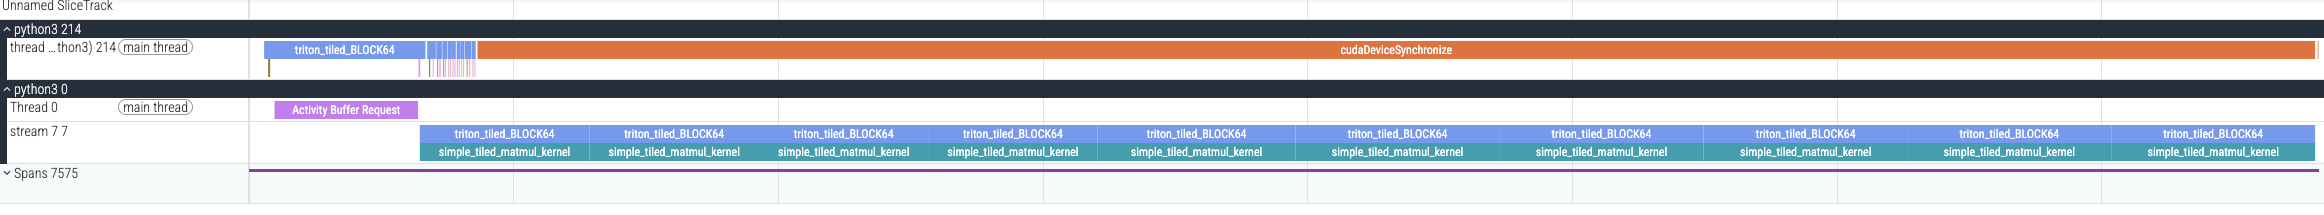

# Ideas/Notes
- Swizzling for better L2 Cache Usage
- Roofline model and placement
- does an FP32-input matmul use the tensor cores?
- Auto-tuning.
- Mixed precision
- Add an FP16-input variant of your tiled kernel
- profile with nsys and ncu
- Integrate in Mobilenet_v1